In [1]:
# ambiente anaconda
import sys
print(sys.executable) # orange3 ou youtube
import sys
print(sys.version)

/home/fabiene/anaconda3/envs/orange3/bin/python
3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]


# Projeto 20: Previsão do preço de ações com redes neurais recorrentes

## Etapa 1: Importação das bibliotecas

In [3]:
import numpy as np
import pandas as pd
# MinMaxScaler transforma valores de 0 e 1, padronizar a mesma escala 
# aplicar a normalização => MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from sklearn.metrics import mean_absolute_error
torch.__version__

'2.9.1+cpu'

Estudo também de Regressão, além de redes neurais recorrentes

In [5]:
torch.manual_seed(123) # gera sempre o mesmo valor, semente

## Etapa 2: Base de dados

In [6]:
# ações da Petrobrás
base = pd.read_csv('petr4_treinamento.csv')

In [7]:
base.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
1240,2017-12-25,15.75,15.750000,15.75,15.750000,15.718563,0.0
1241,2017-12-26,15.75,15.990000,15.69,15.970000,15.938125,22173100.0
1242,2017-12-27,15.99,16.139999,15.98,16.049999,16.017963,23552200.0
1243,2017-12-28,16.10,16.129999,16.00,16.100000,16.067865,19011500.0
1244,2017-12-29,16.10,16.100000,16.10,16.100000,16.067865,0.0


In [8]:
base.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2013-01-02,19.990000,20.209999,19.690001,19.690001,18.086271,30182600.0
1,2013-01-03,19.809999,20.400000,19.700001,20.400000,18.738441,30552600.0
2,2013-01-04,20.330000,20.620001,20.170000,20.430000,18.766001,36141000.0
3,2013-01-07,20.480000,20.670000,19.950001,20.080000,18.444506,28069600.0
4,2013-01-08,20.110001,20.230000,19.459999,19.500000,17.911745,29091300.0


open ação na abertura; high, maior valor, e baixo low; valor do fechamento (close). 

adj close => atribuições com dividendos, valor justo. 

volume de ações negociadas. 


## previsão para janeiro de 2018



In [9]:
base.shape

(1245, 7)

In [10]:
print(f'quantidade de dados {base.shape[0]} e com {base.shape[1]} colunas.')

quantidade de dados 1245 e com 7 colunas.


In [12]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1245 entries, 0 to 1244
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1245 non-null   object 
 1   Open       1242 non-null   float64
 2   High       1242 non-null   float64
 3   Low        1242 non-null   float64
 4   Close      1242 non-null   float64
 5   Adj Close  1242 non-null   float64
 6   Volume     1242 non-null   float64
dtypes: float64(6), object(1)
memory usage: 68.2+ KB


In [13]:
print(base.isnull().sum().sum())

18


In [14]:
print(base.isnull().sum())

Date         0
Open         3
High         3
Low          3
Close        3
Adj Close    3
Volume       3
dtype: int64


In [17]:
base = base.dropna() # deletar dados nulos

In [16]:
print(base.isnull().sum())

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [18]:
print(f'quantidade de dados {base.shape[0]} e com {base.shape[1]} colunas.')

quantidade de dados 1242 e com 7 colunas.


Base de série temporal.

In [21]:
 base.iloc[:,1:2] # coleta apenas a coluna Open

,Open
0,19.990000
1,19.809999
2,20.330000
3,20.480000
4,20.110001
...,...
1240,15.750000
1241,15.750000
1242,15.990000
1243,16.100000


In [22]:
 base.iloc[:,1:2].columns

Index(['Open'], dtype='object')

In [23]:
base_treinamento = base.iloc[:, 1:2].values # formato em numpy array os dados do open

In [24]:
base_treinamento

array([[19.99    ],
       [19.809999],
       [20.33    ],
       ...,
       [15.99    ],
       [16.1     ],
       [16.1     ]])

In [26]:
# colocar como normalizador
normalizador = MinMaxScaler(feature_range=(0,1))
base_treinamento_normalizada = normalizador.fit_transform(base_treinamento)

In [27]:
# colocado na escala de 0 a 1
base_treinamento_normalizada

array([[0.76501938],
       [0.7562984 ],
       [0.78149225],
       ...,
       [0.57122093],
       [0.57655039],
       [0.57655039]])

transformar a base neste formato

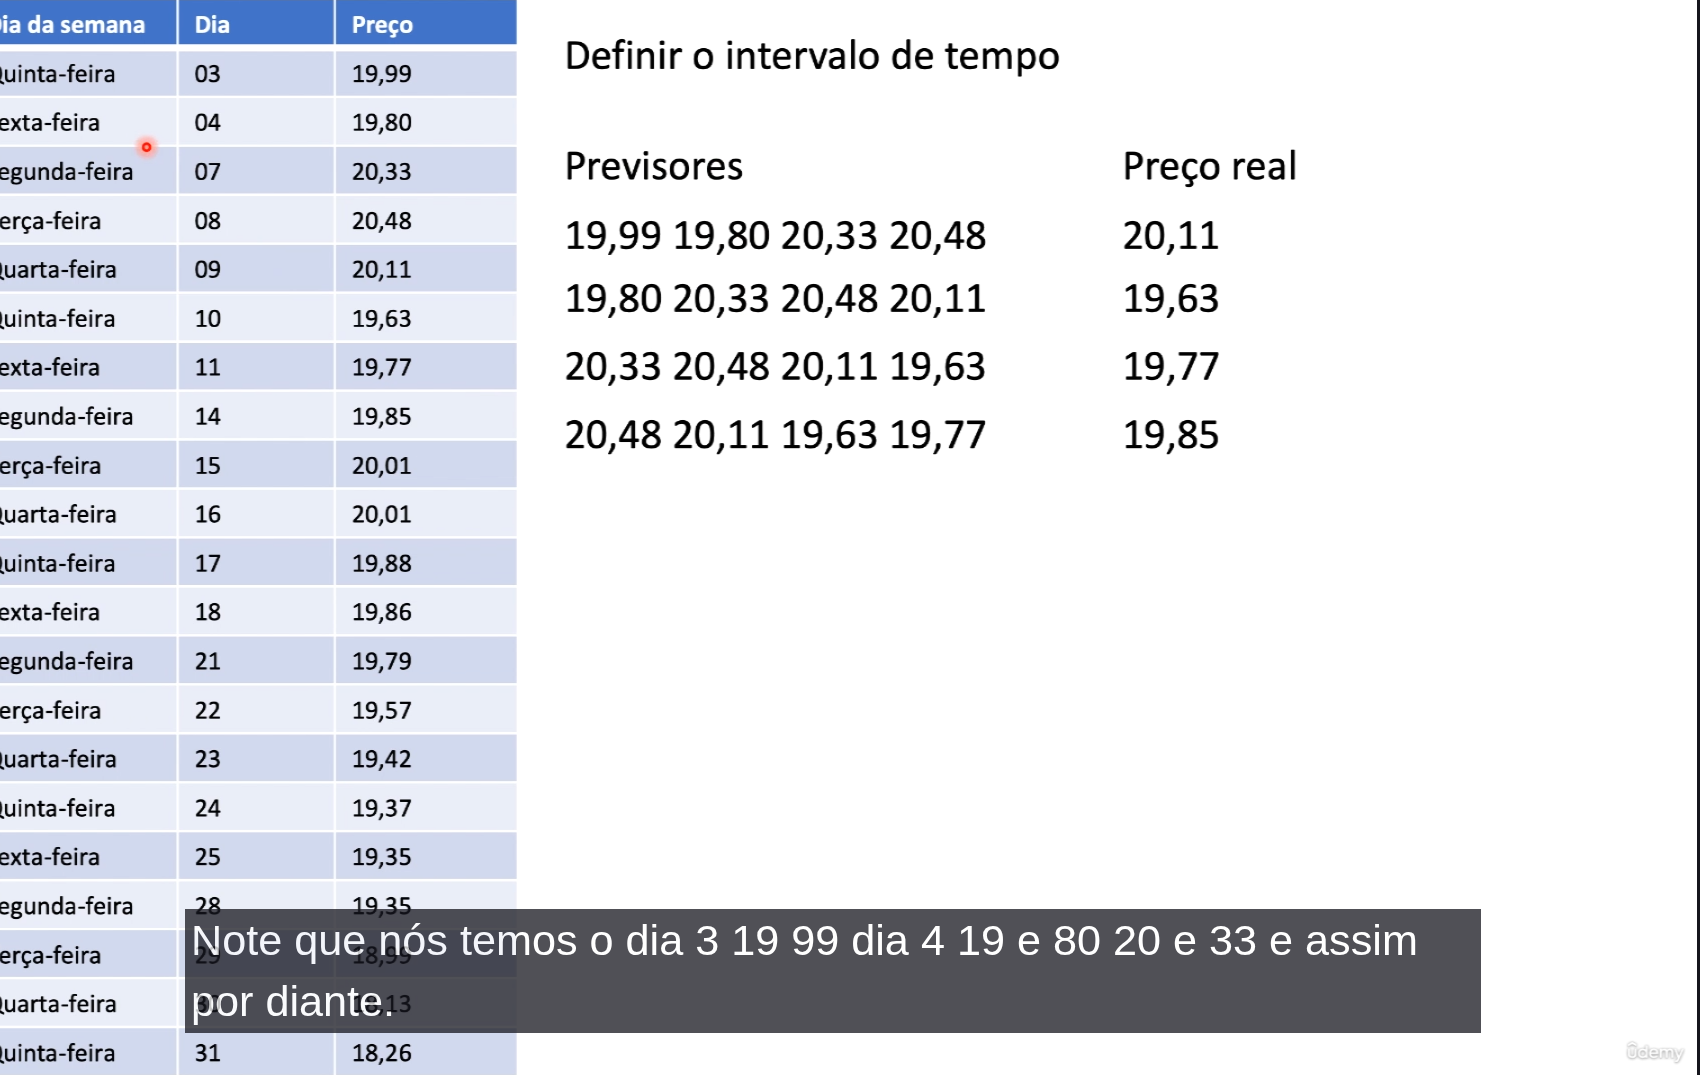

prever a ação com base em 4 valores anteriores, com o objetivo no próximo atributo, o valor quinto real e comparar.

deslocamento para frente o valor da previsão. 


In [33]:
# criar duas variáveis de comparação
# Vai guardar as "sequências" (o passado)
X = []# previsores
# Vai guardar os "alvos" (o que a rede deve prever no futuro)
y = []# valores reais
for i in range(90, 1242): # precisa ter os valores reais sem se mexer, 90 dados atrás
  # começar dos dados 90 em diante  
  # valor final 1242
  # Pega os 90 dias anteriores (de i-90 até i)
  X.append(base_treinamento_normalizada[i-90:i, 0])
  # Pega o valor do dia atual (índice i) para ser a resposta correta    
  y.append(base_treinamento_normalizada[i, 0])
X, y = np.array(X), np.array(y)

In [34]:
X[0] #90 anteriores

array([0.76501938, 0.7562984 , 0.78149225, 0.78875969, 0.77083338,
       0.74806197, 0.75436047, 0.75823643, 0.76598837, 0.76598837,
       0.76017437, 0.75872098, 0.75581391, 0.74467054, 0.7374031 ,
       0.7374031 , 0.73498067, 0.75242248, 0.73401163, 0.71656977,
       0.68120155, 0.67538755, 0.67635659, 0.63372098, 0.66521318,
       0.65649225, 0.64680228, 0.66618222, 0.65843028, 0.64970935,
       0.65116274, 0.66424419, 0.67344961, 0.64292631, 0.64486434,
       0.62257747, 0.60949617, 0.60998067, 0.60852713, 0.59593023,
       0.61143411, 0.60222863, 0.64922481, 0.68362398, 0.70687989,
       0.68265509, 0.70978682, 0.70784879, 0.71608527, 0.73643411,
       0.7122093 , 0.7122093 , 0.7194767 , 0.70348832, 0.69525189,
       0.70397287, 0.70397287, 0.69767442, 0.68168605, 0.68168605,
       0.65310078, 0.66618222, 0.64825581, 0.66182175, 0.64341085,
       0.67877902, 0.69137592, 0.66569772, 0.65406982, 0.64292631,
       0.64147292, 0.63565891, 0.67587209, 0.68653106, 0.70300

In [35]:
y[0] # próximo valor

0.7611434108527131

In [36]:
# posição deslocada, 90 dias passado
X[1]

array([0.7562984 , 0.78149225, 0.78875969, 0.77083338, 0.74806197,
       0.75436047, 0.75823643, 0.76598837, 0.76598837, 0.76017437,
       0.75872098, 0.75581391, 0.74467054, 0.7374031 , 0.7374031 ,
       0.73498067, 0.75242248, 0.73401163, 0.71656977, 0.68120155,
       0.67538755, 0.67635659, 0.63372098, 0.66521318, 0.65649225,
       0.64680228, 0.66618222, 0.65843028, 0.64970935, 0.65116274,
       0.66424419, 0.67344961, 0.64292631, 0.64486434, 0.62257747,
       0.60949617, 0.60998067, 0.60852713, 0.59593023, 0.61143411,
       0.60222863, 0.64922481, 0.68362398, 0.70687989, 0.68265509,
       0.70978682, 0.70784879, 0.71608527, 0.73643411, 0.7122093 ,
       0.7122093 , 0.7194767 , 0.70348832, 0.69525189, 0.70397287,
       0.70397287, 0.69767442, 0.68168605, 0.68168605, 0.65310078,
       0.66618222, 0.64825581, 0.66182175, 0.64341085, 0.67877902,
       0.69137592, 0.66569772, 0.65406982, 0.64292631, 0.64147292,
       0.63565891, 0.67587209, 0.68653106, 0.70300383, 0.71996

In [37]:
y[1] # próximo valor

0.7611434108527131

In [38]:
# Transforma o array do NumPy 'X' (que contém as sequências de 90 dias) 
# em um Tensor do PyTorch.
# dtype=torch.float32: Garante que os números sejam pontos flutuantes de 32 bits.
# Isso é o padrão para redes neurais; usar 64 bits (double) deixaria o treino lento.
X = torch.tensor(X, dtype=torch.float32)

# Faz o mesmo com o 'y' (que contém o valor que queremos prever).
# Agora, tanto os dados de entrada quanto os alvos estão no formato 
# que as funções de perda (Loss Functions) e os otimizadores do PyTorch exigem.
y = torch.tensor(y, dtype=torch.float32)

In [39]:
# Cria o Dataset: torch.utils.data.TensorDataset(X, y)
# O TensorDataset funciona como um "grampeador". Ele une o seu tensor de entrada (X) 
# ao seu tensor de resposta (y). Isso garante que, durante o treino, cada sequência 
# de 90 dias esteja perfeitamente alinhada com o valor que a rede deve prever.
dataset = torch.utils.data.TensorDataset(X, y)

# Cria o Loader: torch.utils.data.DataLoader(dataset, ...)
# O DataLoader é o "gerente de logística" que entrega os dados para a rede neural:
# - batch_size=32: Em vez de processar uma linha por vez, ele agrupa os dados em 
#   pacotes de 32. Isso acelera o treino e torna o aprendizado mais estável.
# - shuffle=True: Ele "embaralha as cartas" a cada época. Isso força a rede a 
#   aprender os padrões reais dos dados, em vez de apenas decorar a ordem das datas.
loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

## Etapa 3: Construção da rede neural recorrente

In [43]:
class regressor_LSTM(nn.Module):
  def __init__(self):
    # construção super classe  
    super().__init__()

    # Primeira camada LSTM: recebe 1 valor (input_size=1) e gera 100 características internas.
    # É aqui que a rede começa a identificar padrões na janela de 90 dias.
    # única dimensão, open 1 coluna ou atributos => input_size = 1.
      
    # hidden_size: The number of features in the hidden state 'h',quantos desdobramentos que a rede neural recorrente vai fazer. 
    # (hidden_size? numero de caracterísitas tem no hidden state h) 
    self.lstm1 = nn.LSTM(input_size=1, hidden_size=100)
    
    # Segunda camada LSTM: recebe as 100 características da anterior e reduz para 50.
    # Serve para refinar a interpretação dos dados temporais.
    # camadas ocultas agora,  input_size 100 e o hidden_size 50;
    self.lstm2 = nn.LSTM(100, 50)
    
    # Terceira camada LSTM: possui 2 camadas internas (num_layers=2) e dropout de 0.3.
    # O dropout aqui ajuda a evitar que a rede decore os dados (overfitting). Zerar 30% dos neurônios
    self.lstm3 = nn.LSTM(50, 50, dropout = 0.3, num_layers=2)
    #num_layers=2 number of recurrent layers, setting num_layers=2 would mean stacking two LSTMs together to form a stacked LSTM,
    # with the second LSTM taking in outputs of the first LSTM and computing the final results.   
    # colocar 2 neurônios juntos em forma de pilhas, uma camada sobre a outra => stacking.  
      
    # Camada de Dropout extra: desativa 30% dos neurônios aleatoriamente durante o treino.
    self.dropout = nn.Dropout(p = 0.3) # entre as camadas
    
    # Camada Linear (Densa): transforma as 50 características finais em 1 único valor de saída.
    # Esse "1" é a sua previsão final (o valor de amanhã, por exemplo).
    # vai receber 50, definido na camada lstm3, out_features, valores das saídas, uma coluna
    # várias camadas recursiva, e no final teremos que ter apenas um valor final.
    self.linear = nn.Linear(in_features=50, out_features=1)

  def forward(self, X):
    # (batch_size, timesteps) -> (timesteps, batch_size, dimensions)
    # timesteps quantos passos para frente, no caso 90 dados  
    #  (timesteps=90, batch_size, dimensions)
      
    # Permute mudar a ordem dos dados que estão entrando 1 em primeiro e 0 em segundo lugar
    # unsqueeze 2
    # Permute e Unsqueeze: O PyTorch espera LSTMs no formato (Tempo, Lote, Dimensão).
    # Como meus dados vêm como (Lote, Tempo), o permute inverte e o unsqueeze adiciona a dimensão final.
    X = X.permute(1, 0).unsqueeze(2)
      
    # abixo liga as lstm para a outra  
    
    # Passa pela 1ª LSTM. O "_" ignora o estado da memória (hidden state) que não usaremos agora.
    # não trabalha com o dado oculto da célula _
    X, _ = self.lstm1(X)
    X = self.dropout(X) # Aplica dropout para regularização.
    
    # Passa pela 2ª LSTM para extrair padrões mais profundos.
    X, _ = self.lstm2(X)
    X = self.dropout(X)
    
    # Passa pela 3ª LSTM (a mais complexa da rede).
    X, _ = self.lstm3(X)
    # output para cada um do outstep, queremos apenas 1 valor 

    # X = X[-1]: Pega apenas o último "passo" da sequência temporal. 
    # Como queremos prever o futuro, o último estado da memória é o mais importante.
    X = X[-1]
    
    # Aplica o dropout final e passa pela camada linear para chegar ao número previsto.
    X = self.dropout(X)
    X = self.linear(X)

    return X

In [44]:
# torch.cuda.is_available(): Verifica se o computador tem uma placa de vídeo NVIDIA 
# configurada e pronta para uso com o Driver CUDA.

# torch.device('cuda'): Se a placa existir, o 'device' será configurado para usar a GPU. 
# Isso torna o treinamento da LSTM até 50x mais rápido que no processador.

# torch.device('cpu'): Se não houver placa de vídeo, o PyTorch usará o processador central. 
# Funciona, mas para redes complexas como LSTMs, pode demorar bastante.

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Exibe qual hardware foi selecionado (vai imprimir 'cuda' ou 'cpu' no console).
device

device(type='cpu')

In [45]:
# Instancia a classe do modelo que se criou: regressor_LSTM()
# Cria o objeto 'regressor', que contém todos os neurônios e camadas da sua LSTM.
regressor = regressor_LSTM()

# Define a Função de Perda: nn.MSELoss() (Mean Squared Error)
# O Erro Quadrático Médio é o padrão para problemas de Regressão (prever números).
# Ele calcula a diferença entre o valor que a rede previu e o valor real, 
# eleva ao quadrado (para penalizar erros grandes) e tira a média.
criterion = nn.MSELoss()

# Atenção: caso você tenha sempre os mesmos resultados de previsões, utilize os parâmetros lr e alpha abaixo

# Define o Otimizador: optim.RMSprop(...)
# O RMSprop é um algoritmo de otimização excelente para Séries Temporais e LSTMs. ****
# - regressor.parameters(): Diz ao otimizador quais pesos da rede ele deve ajustar.
# - lr = 1e-3 (0.001): A Taxa de Aprendizado. Controla o tamanho do "passo" no ajuste.
# - alpha = 0.9: Um fator de suavização que ajuda a manter o aprendizado estável,
#   evitando que o modelo "se perca" caso os dados oscilem demais (como ações).
optimizer = optim.RMSprop(regressor.parameters(), lr = 1e-3, alpha = 0.9)

In [47]:
# regressor.to(device):
# Envia o modelo para o hardware selecionado (GPU/CUDA ou CPU).
# Sem esse comando, o modelo ficaria na CPU por padrão. Se você tentar 
# treinar dados que estão na GPU em um modelo que está na CPU, o PyTorch 
# travará com um erro de "RuntimeError: Expected all tensors to be on the same device".


In [46]:
regressor.to(device)

regressor_LSTM(
  (lstm1): LSTM(1, 100)
  (lstm2): LSTM(100, 50)
  (lstm3): LSTM(50, 50, num_layers=2, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)

## Etapa 4: Treinamento do modelo

In [48]:
# Listas para armazenar o histórico e permitir a plotagem do gráfico depois
historico_loss = []
historico_mae = []

# Início do loop de épocas (o modelo verá o dataset completo 100 vezes)
for epoch in range(100):
    running_loss = 0.  # Acumula o erro quadrático (MSE) da época
    running_mae = 0.   # Acumula o erro médio absoluto (MAE) da época

    # Loop para percorrer cada pacote (batch) de 32 sequências, passar de 32 e 32 registros (definindo acima)
    # batch_size=32;
    for i, data in enumerate(loader):
        # Desempacota os dados: inputs (90 dias) e labels (valor real do dia seguinte)
        inputs, labels = data
        
        # Envia os dados para a GPU (Cuda) ou CPU, conforme configurado no 'device'
        inputs, labels = inputs.to(device), labels.to(device)

        # Zera os gradientes acumulados. Essencial para que o erro de um lote 
        # não influencie o ajuste do próximo lote de forma errada.
        optimizer.zero_grad()

        # Feedforward: Passa os dados pela rede LSTM para obter a previsão
        # teremos os valores das previsões para todos os registros
        outputs = regressor(inputs)
        
        # Achata a saída para garantir que tenha o mesmo formato vetorial dos rótulos
        # trasformar em forma de vetor
        # achatar os valores dos outputs, para estar no mesmo formato do valore real para comparar no loss
        outputs = outputs.flatten()

        # Calcula o Custo (Loss): Quão longe a previsão está do valor real (MSE)
        loss = criterion(outputs, labels)
        
        # Backpropagation: Calcula a derivada do erro em relação a cada peso da rede
        loss.backward()

        # Atualização: O otimizador ajusta os pesos dos neurônios para diminuir o erro
        optimizer.step()

        # Soma o valor do custo atual ao total da época (.item() extrai o número do tensor)
        running_loss += loss.item()

        # Cálculo do MAE: Transforma em NumPy para medir o erro médio em unidades reais
        # LABELS REAL E outputs previsão
        # tirar o valor do tensor detach
        mae = mean_absolute_error(labels.detach().cpu().numpy().flatten(),
                                  outputs.detach().cpu().numpy().flatten())
        running_mae += mae
        
        # Imprimindo os dados referentes a esse loop
        # Imprime o progresso em tempo real na mesma linha (\r)
        print('\rÉpoca {:3d} - Loop {:3d} de {:3d}: custo {:03.5f} - MAE {:03.5f}'.format(
            epoch+1, i+1, len(loader), loss, mae), end = '\r')
        
    # Imprimindo os dados referentes a essa época
    # Calcula a média do erro dividindo pelo número de pacotes (batches) processados
    epoca_loss = running_loss / len(loader)
    epoca_mae = running_mae / len(loader)
    
    # Salva as médias nas listas de histórico para gerar o gráfico ao final
    historico_loss.append(epoca_loss)
    historico_mae.append(epoca_mae)

    # Mensagem de encerramento da época com o resumo do aprendizado
    print('ÉPOCA {:3d} FINALIZADA: custo {:03.6f} - MAE {:03.6f}      '.format(
        epoch+1, epoca_loss, epoca_mae))

ÉPOCA   1 FINALIZADA: custo 0.053359 - MAE 0.183821      
ÉPOCA   2 FINALIZADA: custo 0.027667 - MAE 0.133148      
ÉPOCA   3 FINALIZADA: custo 0.016916 - MAE 0.101662      
ÉPOCA   4 FINALIZADA: custo 0.013010 - MAE 0.089508      
ÉPOCA   5 FINALIZADA: custo 0.010683 - MAE 0.080629      
ÉPOCA   6 FINALIZADA: custo 0.009950 - MAE 0.076743      
ÉPOCA   7 FINALIZADA: custo 0.008608 - MAE 0.073153      
ÉPOCA   8 FINALIZADA: custo 0.008166 - MAE 0.070127      
ÉPOCA   9 FINALIZADA: custo 0.006733 - MAE 0.063800      
ÉPOCA  10 FINALIZADA: custo 0.006055 - MAE 0.061385      
ÉPOCA  11 FINALIZADA: custo 0.006219 - MAE 0.060925      
ÉPOCA  12 FINALIZADA: custo 0.006026 - MAE 0.059724      
ÉPOCA  13 FINALIZADA: custo 0.005432 - MAE 0.057227      
ÉPOCA  14 FINALIZADA: custo 0.005562 - MAE 0.057369      
ÉPOCA  15 FINALIZADA: custo 0.004526 - MAE 0.051745      
ÉPOCA  16 FINALIZADA: custo 0.004962 - MAE 0.054411      
ÉPOCA  17 FINALIZADA: custo 0.004583 - MAE 0.052864      
ÉPOCA  18 FINA

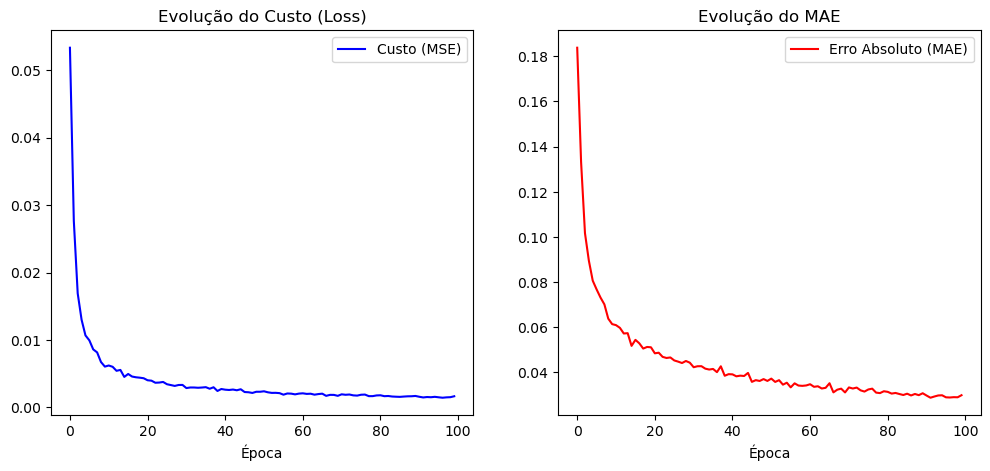

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Gráfico do Custo (Loss/MSE) - Mostra a convergência matemática
plt.subplot(1, 2, 1)
plt.plot(historico_loss, label='Custo (MSE)', color='blue')
plt.title('Evolução do Custo (Loss)')
plt.xlabel('Época')
plt.legend()

# Gráfico do MAE - Mostra o erro médio "na prática"
plt.subplot(1, 2, 2)
plt.plot(historico_mae, label='Erro Absoluto (MAE)', color='red')
plt.title('Evolução do MAE')
plt.xlabel('Época')
plt.legend()

plt.show()

Curva de "L": Se as linhas descem rápido e depois ficam quase retas, parabéns! Seu modelo convergiu e aprendeu o máximo que podia com esses dados.

Linha "Serra": Se o gráfico sobe e desce muito bruscamente (instabilidade), talvez o seu lr (taxa de aprendizado) no RMSprop esteja alto demais.

Linha Reta (no topo): Se a linha não desce, o modelo não está aprendendo. Verifique se a normalização dos dados foi feita corretamente.

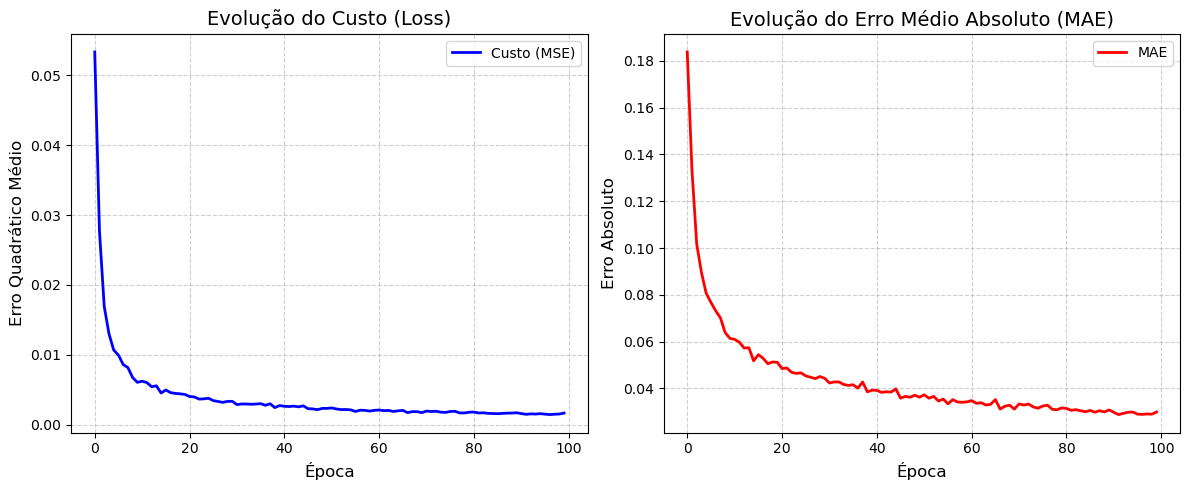

In [50]:
import matplotlib.pyplot as plt

# Define o tamanho da figura (largura, altura)
plt.figure(figsize=(12, 5))

# --- GRÁFICO 1: Custo (Loss/MSE) ---
# O MSE (Mean Squared Error) é a métrica que o otimizador usa para ajustar os pesos.
plt.subplot(1, 2, 1) # Cria o primeiro gráfico de uma grade 1x2
plt.plot(historico_loss, label='Custo (MSE)', color='blue', linewidth=2)
plt.title('Evolução do Custo (Loss)', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Erro Quadrático Médio', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) # Adiciona uma grade leve para facilitar a leitura
plt.legend()

# --- GRÁFICO 2: Erro Médio Absoluto (MAE) ---
# O MAE mostra o erro médio na mesma unidade dos seus dados originais.
plt.subplot(1, 2, 2) # Cria o segundo gráfico
plt.plot(historico_mae, label='MAE', color='red', linewidth=2)
plt.title('Evolução do Erro Médio Absoluto (MAE)', fontsize=14)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Erro Absoluto', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Ajusta o espaçamento entre os gráficos para não sobrepor os títulos
plt.tight_layout()
plt.show()

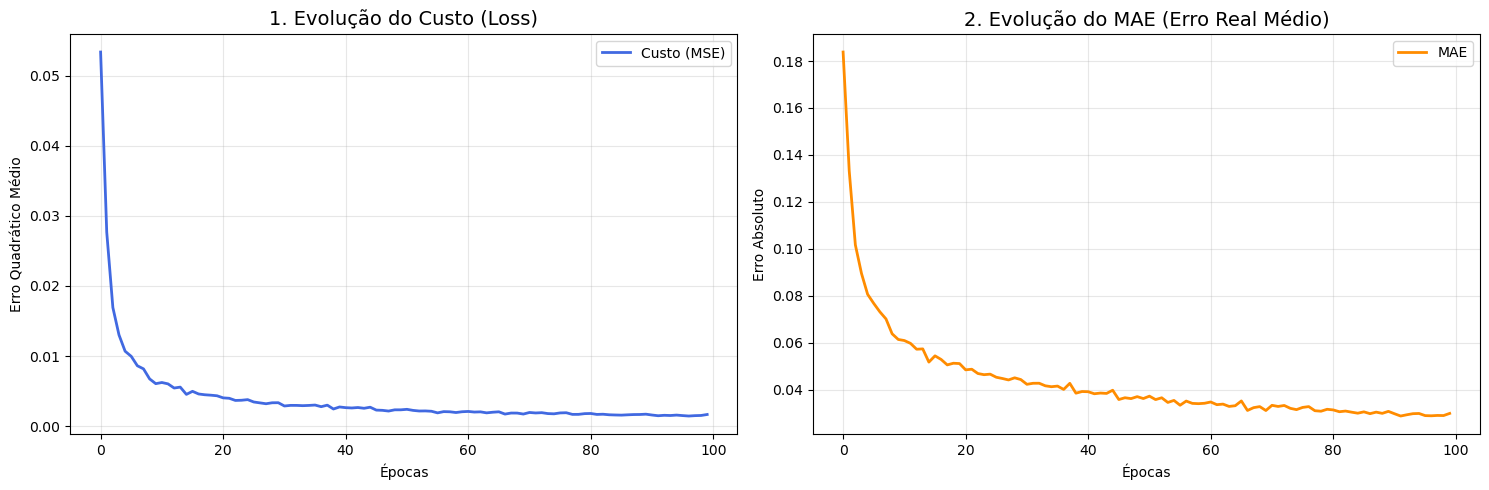

In [54]:
import matplotlib.pyplot as plt

# Define o tamanho da imagem (largura, altura)
plt.figure(figsize=(15, 5))

# --- GRÁFICO 1: Custo (Loss/MSE) ---
# O MSE é o que a rede usa para "aprender". Ele penaliza erros grandes.
plt.subplot(1, 2, 1) 
plt.plot(historico_loss, label='Custo (MSE)', color='royalblue', linewidth=2)
plt.title('1. Evolução do Custo (Loss)', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Erro Quadrático Médio')
plt.legend()
plt.grid(True, alpha=0.3)

# --- GRÁFICO 2: Erro Médio Absoluto (MAE) ---
# O MAE é mais fácil de entender: ele diz, em média, quanto a previsão errou no valor real.
plt.subplot(1, 2, 2)
plt.plot(historico_mae, label='MAE', color='darkorange', linewidth=2)
plt.title('2. Evolução do MAE (Erro Real Médio)', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Erro Absoluto')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout() # Ajusta o espaçamento para não amassar os títulos
plt.savefig('erro_m13.png', dpi=300, bbox_inches='tight')

plt.show()


1. O Cenário Ideal (Sucesso)
   
O que acontece: Ambas as curvas descem rapidamente no início e depois "estacionam" (formam um desenho de "L").

O que significa: A rede encontrou os padrões dos 90 dias anteriores e o erro parou de cair porque ela já aprendeu o que era possível.

2. O Cenário de Instabilidade (Problema no Otimizador)
   
O que acontece: O gráfico parece uma "serra", subindo e descendo loucamente a cada época.

O que significa: A sua Taxa de Aprendizado (lr) está muito alta. O otimizador está dando passos tão grandes que ele "pula" o ponto de acerto e cai no erro de novo. Se isso acontecer, tente diminuir o lr para 1e-4.

3. O Cenário de "Overfitting" (Decoreba)
   
O que acontece: O Custo (Loss) continua descendo muito, mas se você testar com dados novos, o erro é alto.

O que significa: A rede decorou o ruído dos dados. É por isso que usamos o Dropout (0.3) no seu código — ele serve justamente para impedir que a curva desça "perfeitamente" demais por puro vício.

Qual foi o valor final do seu MAE? Se ele estiver bem baixo (perto de 0.02 ou 0.05, dependendo da sua escala), sua rede está pronta para prever o futuro!

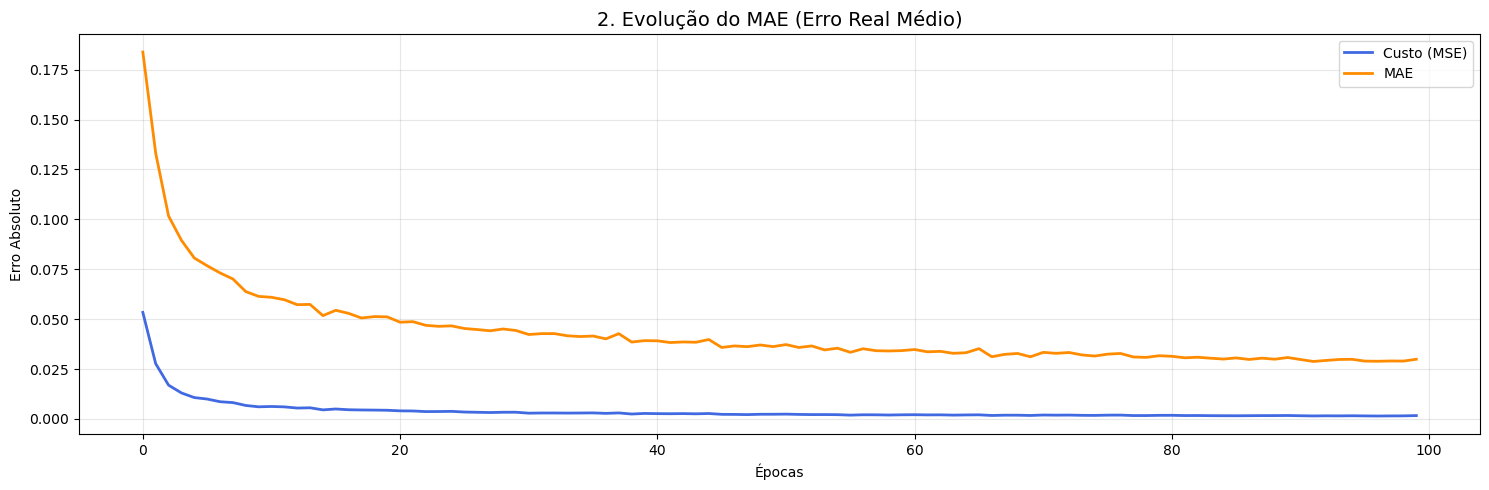

In [52]:
import matplotlib.pyplot as plt

# Define o tamanho da imagem (largura, altura)
plt.figure(figsize=(15, 5))

# --- GRÁFICO 1: Custo (Loss/MSE) ---
# O MSE é o que a rede usa para "aprender". Ele penaliza erros grandes.
#plt.subplot(1, 2, 1) 
plt.plot(historico_loss, label='Custo (MSE)', color='royalblue', linewidth=2)
plt.title('1. Evolução do Custo (Loss)', fontsize=14)
plt.xlabel('Épocas')
#plt.ylabel('Erro Quadrático Médio')
plt.legend()
plt.grid(True, alpha=0.3)

# --- GRÁFICO 2: Erro Médio Absoluto (MAE) ---
# O MAE é mais fácil de entender: ele diz, em média, quanto a previsão errou no valor real.
#plt.subplot(1, 2, 2)
plt.plot(historico_mae, label='MAE', color='darkorange', linewidth=2)
plt.title('2. Evolução do MAE (Erro Real Médio)', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Erro Absoluto')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout() # Ajusta o espaçamento para não amassar os títulos
plt.show()

🔍 Análise do seu Treinamento

Convergência Rápida: Nas primeiras 20 épocas, o erro cai drasticamente. Isso mostra que a rede identificou rapidamente os padrões mais óbvios da sua série temporal (a tendência geral dos dados).

Estabilidade (Platô): Após a época 40, as curvas ficam mais "suaves" e quase horizontais. Isso significa que o seu Learning Rate (1e-3) e o RMSprop estão bem ajustados; a rede não está "pulando" o ponto de acerto, ela está apenas refinando os detalhes.

Bons Valores Finais:

O  MSE (Custo) terminou muito próximo de 0.002.

O  MAE (Erro Real) terminou abaixo de 0.04.

Tradução prática: Se os dados estiverem na escala de 0 a 1 (normalizados), o erro médio é de apenas 4%. É uma precisão excelente para previsões!

💡 Por que tem essas "onadinhas" no gráfico laranja (MAE):

Essas pequenas oscilações são normais e saudáveis. Elas acontecem por dois motivos:

Dropout: Como você usou dropout=0.3, a rede desliga neurônios aleatórios a cada passo. Isso gera uma pequena variação no erro, mas impede que a rede "decore" os dados (overfitting).

Shuffle: Como os dados são embaralhados no DataLoader, a cada época a rede vê sequências em ordens diferentes.